In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
from catboost import CatBoostRegressor
from hyperopt import hp, tpe, Trials, STATUS_OK, fmin
from hyperopt.early_stop import no_progress_loss
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")
from flaml import AutoML
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import shap
from tqdm import tqdm
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, 
    AdaBoostRegressor, BaggingRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    Lasso, LassoLars, LinearRegression, Ridge,
    SGDRegressor, PassiveAggressiveRegressor, ElasticNet, HuberRegressor,
    BayesianRidge, OrthogonalMatchingPursuit
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import NuSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [2]:
train=pd.read_csv('/home/ychen3338/proj_2/CO2/train_data.csv')
test=pd.read_csv('/home/ychen3338/project_2/data/test_data.csv')

In [3]:
class morgan_fp:
    def __init__(self, radius, length):
        self.radius = radius
        self.length = length
    def __call__(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, self.radius, self.length)
        npfp = np.array(list(fp.ToBitString())).astype('float32')
        return npfp

In [4]:
def conv_data(data, fp):
    data['c-fp'] = data['Cation'].apply(fp)
    x_c=np.array(list(data['c-fp']))
    data['a-fp'] = data['Anion'].apply(fp)
    x_a=np.array(list(data['a-fp']))
    x_con = data[['T', 'P']].values
    xx = np.concatenate([x_c, x_a, x_con], axis =1)
    y = data['co2'].values
    return xx, y

In [5]:
# result = pd.read_csv('/home/ychen3338/project_2/code/co2/CO2_MF.csv')
# result.sort_values('loss', ascending= True, inplace = True)
# result.reset_index(drop = True, inplace =True)
# result.head()

In [6]:
# import ast
# params = result.loc[0, 'params']
# params = ast.literal_eval(params)

In [7]:
# params

{'bagging_temperature': 92.57058985990918, 'depth': 6, 'fp_length': 1214, 'fp_radius': 1, 'iterations': 981, 'l2_leaf_reg': 3.0285439673449828, 'learning_rate': 0.024975070346588985, 'random_strength': 1.0926173812332063}   0.20114361007812623

{'bagging_temperature': 28.396248490437944, 'depth': 6, 'fp_length': 3938, 'fp_radius': 3, 'iterations': 942, 'l2_leaf_reg': 3.074591063145627, 'learning_rate': 0.024950092671883424, 'random_strength': 1.088051605064384}     0.194556

In [5]:
params ={'bagging_temperature': 92.57058985990918, 'depth': 6, 
         'fp_length': 1214, 'fp_radius': 1, 
         'iterations': 981, 'l2_leaf_reg': 3.0285439673449828,
          'learning_rate': 0.024975070346588985, 
          'random_strength': 1.0926173812332063}

{'bagging_temperature': 199.33684767223428, 'depth': 6, 'fp_length': 2950, 'fp_radius': 1, 'iterations': 996, 'l2_leaf_reg': 3.208534346914262, 'learning_rate': 0.024735682459765606, 'random_strength': 109.98401426440948}

In [9]:
SEED = 42
models = [
    ('CatBoost', CatBoostRegressor(
        bagging_temperature=92.57058985990918, depth=6, 
        iterations=981, l2_leaf_reg=3.0285439673449828,
        learning_rate=0.024975070346588985, 
        random_strength= 1.0926173812332063)),
    ('XGBoost',  XGBRegressor(random_state=SEED)),
    ('LightGBM', LGBMRegressor(random_state=SEED)),
    ('RandomForest', RandomForestRegressor(random_state=SEED)),
    ('ExtraTrees',  ExtraTreesRegressor(random_state=SEED)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=SEED)),
    ('HistGradientBoosting', HistGradientBoostingRegressor(random_state=SEED)),
    ('DecisionTree', DecisionTreeRegressor(random_state=SEED)),

    ('SVM', make_pipeline(StandardScaler(), SVR())),
    ('NuSVM', make_pipeline(StandardScaler(), NuSVR())),
    ('MLP', make_pipeline(StandardScaler(), MLPRegressor(max_iter=1000, random_state=SEED))),

    ('Lasso', make_pipeline(StandardScaler(), Lasso(random_state=SEED))),
    ('Ridge', make_pipeline(StandardScaler(), Ridge(random_state=SEED))),
    ('ElasticNet', make_pipeline(StandardScaler(), ElasticNet(random_state=SEED))),
    ('LassoLars', LassoLars()),                       
    ('LinearRegression', LinearRegression()),          
    ('SGDRegressor', SGDRegressor(random_state=SEED)),
    ('BayesianRidge', BayesianRidge()),
    ('OrthogonalMatching', OrthogonalMatchingPursuit()),

    ('AdaBoost', AdaBoostRegressor(random_state=SEED)),
    ('Bagging',  BaggingRegressor(random_state=SEED)),

    ('HuberRegressor', HuberRegressor()),
    ('PassiveAggressive', PassiveAggressiveRegressor(random_state=SEED)),
    ('KNN', KNeighborsRegressor())                     
]
fp = morgan_fp(params['fp_radius'], params['fp_length'])
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)

results = []

for name, model in models:
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)
        results.append((name, score))
    except Exception as e:
        print(f"{name} Error: {str(e)}")

sorted_results = sorted(results, key=lambda x: x[1], reverse=True)

print("Algorithm R² Ranking:")
for idx, (name, score) in enumerate(sorted_results, 1):
    print(f"{idx}. {name}: {score:.4f}")

0:	learn: 0.5077228	total: 51.7ms	remaining: 50.7s
1:	learn: 0.5022168	total: 54.6ms	remaining: 26.7s
2:	learn: 0.4969365	total: 57.2ms	remaining: 18.6s
3:	learn: 0.4911864	total: 60.4ms	remaining: 14.7s
4:	learn: 0.4861058	total: 63.8ms	remaining: 12.5s
5:	learn: 0.4811822	total: 67ms	remaining: 10.9s
6:	learn: 0.4762928	total: 69.6ms	remaining: 9.69s
7:	learn: 0.4715790	total: 72ms	remaining: 8.75s
8:	learn: 0.4673957	total: 75ms	remaining: 8.1s
9:	learn: 0.4629492	total: 78.2ms	remaining: 7.59s
10:	learn: 0.4587612	total: 81.2ms	remaining: 7.16s
11:	learn: 0.4543757	total: 83.9ms	remaining: 6.78s
12:	learn: 0.4500978	total: 86.7ms	remaining: 6.46s
13:	learn: 0.4459934	total: 89.2ms	remaining: 6.16s
14:	learn: 0.4420961	total: 91.9ms	remaining: 5.92s
15:	learn: 0.4383057	total: 94.7ms	remaining: 5.71s
16:	learn: 0.4346487	total: 97.9ms	remaining: 5.55s
17:	learn: 0.4311816	total: 101ms	remaining: 5.42s
18:	learn: 0.4276021	total: 104ms	remaining: 5.27s
19:	learn: 0.4244235	total: 107

In [10]:
fp = morgan_fp(params['fp_radius'], params['fp_length'])

automl = AutoML(random_state=42)
n_jobs = 16
time_budget = 1200 # in seconds


In [11]:
automl_settings = {
    "time_budget": time_budget,
    "metric": 'mse',
    "task": 'regression',
    "eval_method": "cv",
    "n_splits": 5,
    "estimator_list": [
        'xgboost', 
        'xgb_limitdepth', 
        'rf', 
        # 'lrl1', 
        'catboost', 
        'extra_tree', 
        'histgb',
        'kneighbor', 
        'sgd', 
        'enet', 
        'lassolars',       
        'lgbm',
    ],
    "n_jobs": n_jobs,  
    "log_file_name": '/home/ychen3338/project_2/code/co2/AutoML_emulator.log',  

}

X, y = conv_data(train, fp)
automl.fit(X_train=X, y_train=y, **automl_settings)
print("Best estimator:", automl.model.estimator)

[flaml.automl.logger: 07-15 01:15:50] {1728} INFO - task = regression
[flaml.automl.logger: 07-15 01:15:50] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 07-15 01:15:50] {1838} INFO - Minimizing error metric: mse
[flaml.automl.logger: 07-15 01:15:50] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'catboost', 'extra_tree', 'histgb', 'kneighbor', 'sgd', 'enet', 'lassolars', 'lgbm']
[flaml.automl.logger: 07-15 01:15:50] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 07-15 01:15:51] {2393} INFO - Estimated sufficient time budget=7188s. Estimated necessary time budget=54s.
[flaml.automl.logger: 07-15 01:15:51] {2442} INFO -  at 0.7s,	estimator xgboost's best error=0.2086,	best estimator xgboost's best error=0.2086
[flaml.automl.logger: 07-15 01:15:51] {2258} INFO - iteration 1, current learner histgb
[flaml.automl.logger: 07-15 01:15:55] {2442} INFO -  at 4.3s,	estimator histgb's best error=0.2089,	best estimator xg

In [12]:
best_model = automl.model.estimator
joblib.dump(best_model, 'best_lgbm_model.pkl')

['best_lgbm_model.pkl']

In [13]:
best_model = joblib.load('/home/ychen3338/project_2/code/co2/best_lgbm_model.pkl')

In [14]:
fp = morgan_fp(params['fp_radius'], params['fp_length'])

In [15]:
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)
best_model.fit(X_train, y_train)
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

In [16]:
print("Train R2: {:.4f}, MSE: {:.4f}".format(r2_score(y_train, y_train_pred), mean_squared_error(y_train, y_train_pred)))
print("Test  R2: {:.4f}, MSE: {:.4f}".format(r2_score(y_test, y_test_pred), mean_squared_error(y_test, y_test_pred)))

Train R2: 0.9699, MSE: 0.0080
Test  R2: 0.9038, MSE: 0.0256


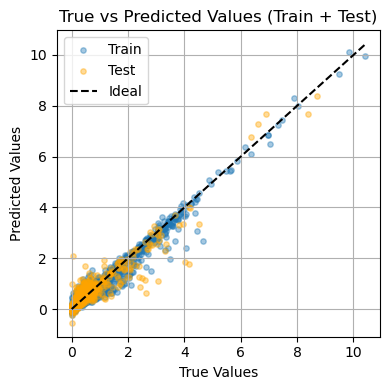

In [17]:
plt.figure(figsize=(4,4))

plt.scatter(y_train, y_train_pred, label='Train', alpha=0.4, s=15)
plt.scatter(y_test, y_test_pred, label='Test', alpha=0.4, s=15, color='orange')

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values (Train + Test)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

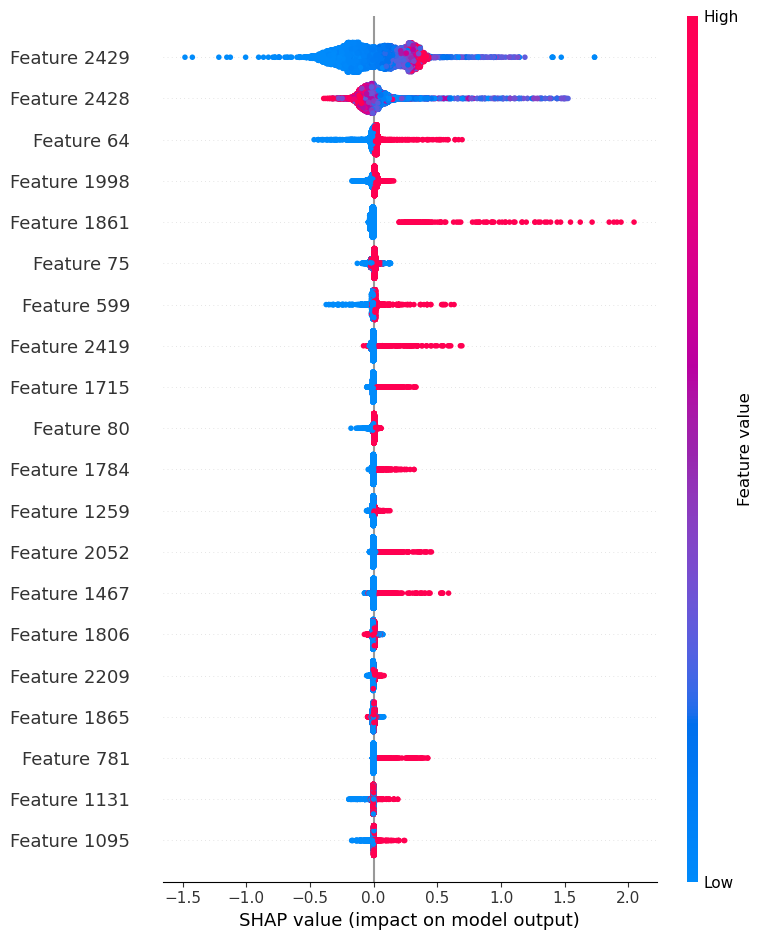

In [18]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train, check_additivity=False)

shap.summary_plot(shap_values, X_train, max_display=20, color_bar=True,show=False)
plt.show()

In [19]:
# Convert SHAP values to a DataFrame
shap_values_df = pd.DataFrame(shap_values.values, columns=[f'Position_{i}' for i in range(X_train.shape[1])])

# Initialize a list to store mean SHAP values for positions where MF == 1
mean_shap_values = []

# Iterate over each position (feature) in the fingerprint
for i in range(X_train.shape[1]):
    # Filter SHAP values where the feature (fingerprint position) is set to 1
    shap_values_at_1 = shap_values_df[X_train[:, i] == 1][f'Position_{i}']

    # Calculate the mean SHAP value at this position when MF == 1
    mean_shap_value = shap_values_at_1.mean()
    mean_shap_values.append(mean_shap_value)

# Create a DataFrame to store the result
mean_shap_df = pd.DataFrame({
    'Position': range(len(mean_shap_values)),
    'Mean_SHAP_Value': mean_shap_values
})

print(mean_shap_df)

      Position  Mean_SHAP_Value
0            0              NaN
1            1         0.004882
2            2              NaN
3            3              NaN
4            4         0.000000
...        ...              ...
2425      2425              NaN
2426      2426              NaN
2427      2427         0.000000
2428      2428              NaN
2429      2429        -0.371306

[2430 rows x 2 columns]


In [20]:
mean_shap_df.to_csv('/home/ychen3338/project_2/code/co2/shap_feature_co2.csv', index=False)

In [21]:
mean_shap_df= pd.read_csv('/home/ychen3338/project_2/code/co2/shap_feature_co2.csv')
print(mean_shap_df)

      Position  Mean_SHAP_Value
0            0              NaN
1            1         0.004882
2            2              NaN
3            3              NaN
4            4         0.000000
...        ...              ...
2423      2423              NaN
2424      2424              NaN
2425      2425              NaN
2426      2426              NaN
2427      2427         0.000000

[2428 rows x 2 columns]


In [ ]:
SHAP_PATH = '/home/ychen3338/project_2/code/co2/shap_feature_co2.csv'
TRAIN_PATH = '/home/ychen3338/project_2/data/train_data.csv'

shap_df = pd.read_csv(SHAP_PATH)
shap_values = shap_df['Mean_SHAP_Value'].values
nonzero_bits = ((~np.isnan(shap_values)) & (shap_values != 0)).astype(int)
negative_bits = ((~np.isnan(shap_values)) & (shap_values > 0)).astype(int)
n_bits = len(nonzero_bits)

nonzero_fp = DataStructs.ExplicitBitVect(n_bits)
negative_fp = DataStructs.ExplicitBitVect(n_bits)
for i in range(n_bits):
    if nonzero_bits[i]:
        nonzero_fp.SetBit(i)
    if negative_bits[i]:
        negative_fp.SetBit(i)

train_df = pd.read_csv(TRAIN_PATH)
train_smiles = train_df['SMILES'].tolist()
train_tms = train_df['co2'].tolist()

In [23]:
dice_scores = []
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=1, nBits=n_bits)
        dice = DataStructs.DiceSimilarity(fp, nonzero_fp)
        dice_scores.append(dice)

p25_dice = np.percentile(dice_scores, 25)
print(f"Step 1: 25th percentile of Dice similarity = {p25_dice:.3f}")

Step 1: 25th percentile of Dice similarity = 0.098


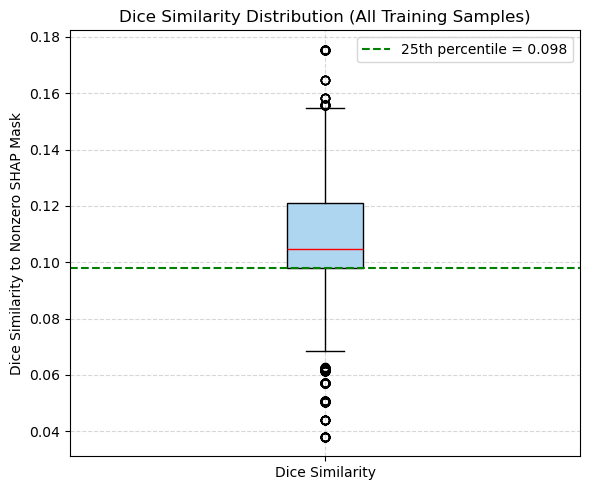

In [24]:
plt.figure(figsize=(6, 5))
plt.boxplot(dice_scores,
            labels=["Dice Similarity"],
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor="#AED6F1"),
            medianprops=dict(color="red"))

plt.axhline(y=p25_dice, color='green', linestyle='--', label=f"25th percentile = {p25_dice:.3f}")

plt.ylabel("Dice Similarity to Nonzero SHAP Mask")
plt.title("Dice Similarity Distribution (All Training Samples)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [25]:
tanimoto_scores_tm_low = []
for smi, co2 in zip(train_smiles, train_tms):
    if co2 <= 0.2:
        continue
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=1, nBits=n_bits)
        tanimoto = DataStructs.TanimotoSimilarity(fp, negative_fp)
        tanimoto_scores_tm_low.append(tanimoto)

tanimoto_scores_all = []
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=1, nBits=n_bits)
        tanimoto = DataStructs.TanimotoSimilarity(fp, negative_fp)
        tanimoto_scores_all.append(tanimoto)

pXX = np.percentile(tanimoto_scores_tm_low, 25)
print(f"Step 2: Tanimoto similarity of samples = {pXX:.3f}")


Step 2: Tanimoto similarity of samples = 0.054


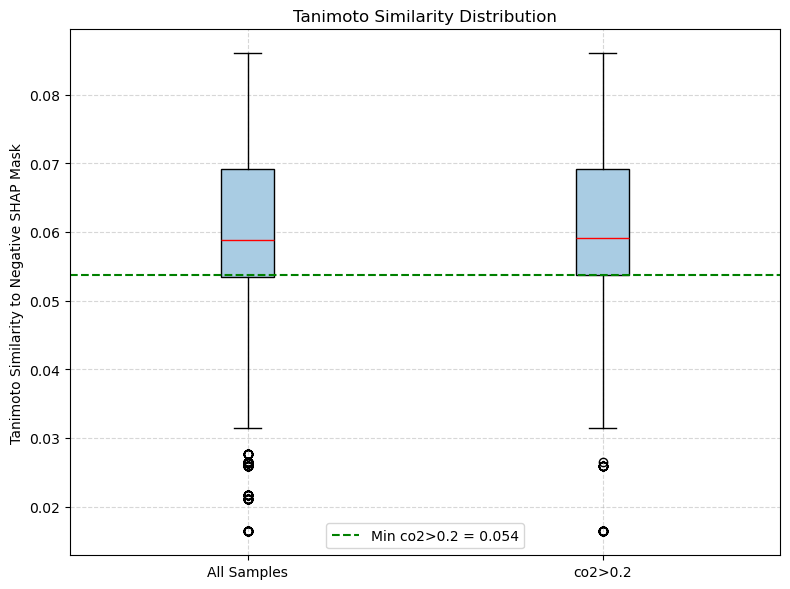

In [26]:
plt.figure(figsize=(8, 6))
plt.boxplot([tanimoto_scores_all, tanimoto_scores_tm_low],
            labels=["All Samples", "co2>0.2"],
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor="#A9CCE3"),
            medianprops=dict(color="red"))

plt.axhline(y=pXX, color='green', linestyle='--', label=f"Min co2>0.2 = {pXX:.3f}")
plt.ylabel("Tanimoto Similarity to Negative SHAP Mask")
plt.title("Tanimoto Similarity Distribution")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [27]:
df = pd.read_csv('/home/ychen3338/project_2/code/co2/simles_co2.csv')

In [28]:
len(df)

179473

In [29]:
df = df.drop_duplicates()
len(df)

179473

In [30]:
df = pd.read_csv('/home/ychen3338/project_2/data/after_m_tox_vis_co2.csv')

In [31]:
len(df)

14121